### Name: Amirhosein Rezaei
### Student ID: 401105989

# Efficient Adaptation of LLMs with QLoRA / LoRA

In this homework we will fine-tune a small instruction model with **parameter-efficient fine-tuning (PEFT)** and compare two adaptation strategies:

1. **Specialized adapters**: one LoRA adapter trained for one dataset.
2. **A general adapter**: one LoRA adapter trained on a mixture of all datasets.

We also evaluate the frozen base model as a baseline, so the adapter results can be interpreted relative to the original model.

The base model is:

```text
Qwen/Qwen2.5-0.5B-Instruct
```

The local dataset directory is assumed to sit next to this notebook and have exactly this structure:

```text
GSM8K/train.json
GSM8K/val.json
CommonsenseQA/train.json
CommonsenseQA/val.json
AGNews/train.json
AGNews/val.json
```

Each training split has 300 examples and each validation split has 100 examples. We will **not** download any datasets from Hugging Face. Only the local JSON files are used.

Full execution trains several adapters sequentially, so use a GPU runtime in Colab or Kaggle. The code is intentionally minimal and readable rather than highly optimized.


## Part 1 — Setup and theory

### Full fine-tuning vs PEFT

In full fine-tuning, every parameter of the base language model is updated. This can work well, but it is expensive: the optimizer must store gradients and optimizer states for all model weights, and each task produces a full copy of the fine-tuned model.

**PEFT** stands for **parameter-efficient fine-tuning**. Instead of updating all model weights, we freeze the base model and train a small number of extra parameters. The result is an **adapter**: a compact task-specific set of weights that can be stored, shared, and swapped in without duplicating the whole base model.

### LoRA intuition

LoRA means **Low-Rank Adaptation**. In a Transformer, many important computations are matrix multiplications. LoRA keeps the original matrix frozen and learns a small low-rank update:

$
W' = W + \Delta W, \quad \Delta W = BA
$

Here, \(W\) is frozen, while \(A\) and \(B\) are trainable smaller matrices. This often gives enough flexibility to adapt the model while training far fewer parameters.

### What does LoRA rank `r` mean?

The rank `r` controls the size of the low-rank update. A larger `r` gives the adapter more capacity, but also trains more parameters and uses more memory. A smaller `r` is cheaper, but may underfit. In this notebook we will compare:

```text
r = 4, 16, 64
```

on CommonsenseQA before choosing one rank for the rest of the experiments.

### QLoRA intuition

QLoRA combines LoRA with low-bit loading of the frozen base model. We load the base model in **4-bit** precision, then train LoRA adapters on top of it. The base model is not updated directly, so 4-bit loading mainly reduces memory use while the small LoRA weights remain trainable.

### Why specialization vs generalization?

A specialized adapter can focus on one task distribution. For example, a GSM8K adapter can spend all of its updates on arithmetic word problems, while an AG News adapter can focus on topic classification. A general adapter sees several tasks and may learn broader behaviors, but its capacity and optimization budget are shared.

This creates a real empirical question:

> Does one general adapter transfer well across tasks, or do specialized adapters perform better in-domain?

### Why matched training budget matters

If the general adapter is trained on the union of three 300-example datasets for the same number of epochs as a specialized adapter, it receives roughly **3× more optimizer updates**. That would make the comparison unfair: better performance might come from more training, not from being more general.

So we will match the optimization budget. A simple way is:

- specialized adapter: train on 300 examples for a small number of epochs;
- general adapter: train on 900 mixed examples for about one third as many epochs, or equivalently for the same number of optimizer updates.

In the code below, the specialized adapters are trained for a fixed number of epochs. We then compute the corresponding optimizer-update budget and use that same update budget for the general adapter.


In [1]:
# Colab/Kaggle setup. Restart the runtime if package installation asks for it.
%pip -q install -U "transformers>=4.45.0" "peft>=0.13.0" "bitsandbytes>=0.43.0" "accelerate>=0.33.0" "datasets>=2.20.0" pandas matplotlib tqdm


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 4.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.7/58.7 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 120.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.2/389.2 kB 34.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 41.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 126.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 128.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.6/78.6 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 14.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour 

In [4]:
import os
# IMPORTANT: hide extra Kaggle/Colab GPUs before importing torch.
# After editing this cell, restart the runtime and run the notebook from the top.
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import gc
import json
import math
import random
import re
import shutil
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from datasets import Dataset
from IPython.display import display
from peft import LoraConfig, PeftModel, get_peft_model, prepare_model_for_kbit_training
from tqdm.auto import tqdm
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig,
    Trainer,
    TrainingArguments,
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

BASE_MODEL = "Qwen/Qwen2.5-0.5B-Instruct"
TASKS = ["GSM8K", "CommonsenseQA", "AGNews"]

# The notebook assumes these folders are beside the notebook.
# On Kaggle you may need to change this to something like Path("/kaggle/input/datasets/<your-name>/<dataset-name>").
DATA_ROOT = Path("./dataset/dataset")

OUTPUT_ROOT = Path("outputs")
ADAPTER_ROOT = OUTPUT_ROOT / "adapters"
RESULTS_ROOT = OUTPUT_ROOT / "results"
ADAPTER_ROOT.mkdir(parents=True, exist_ok=True)
RESULTS_ROOT.mkdir(parents=True, exist_ok=True)

# If a local dataset.zip is placed beside the notebook, this optional block extracts it.
# This is not a dataset download; it only helps when the instructor distributes a zip file.
if not (DATA_ROOT / "GSM8K").exists() and Path("dataset.zip").exists():
    with zipfile.ZipFile("dataset.zip", "r") as zf:
        zf.extractall(DATA_ROOT)

if torch.cuda.is_available():
    print("Visible CUDA devices:", torch.cuda.device_count())
    print("Using GPU:", torch.cuda.get_device_name(0))
else:
    print("No CUDA GPU detected. QLoRA 4-bit training is intended for a GPU runtime.")


Visible CUDA devices: 1
Using GPU: Tesla T4


## Part 2 — Load and inspect the local datasets

We begin by loading the local JSON files and inspecting the schemas we will use most immediately.

GSM8K gives us the math-reasoning format, while CommonsenseQA is the dataset we will use for the LoRA rank ablation. AG News adds a direct news-topic classification task, which is intentionally less reasoning-heavy and gives the comparison a different kind of behavior to measure.

Each example will later become one causal-LM training string:

```text
[prompt text] + [target response] + [end-of-sequence token]
```

During training we mask the prompt tokens in the labels, so the loss is only computed on the target response.

We use simple final-answer markers throughout the notebook:

```text
GSM8K          -> step-by-step reasoning, ending with Answer: <number>
CommonsenseQA -> Answer: <letter>
AG News       -> Answer: World, Sports, Business, or Sci/Tech
```

GSM8K is different from the other two tasks: we train the model to produce a short worked solution before the final answer. CommonsenseQA and AG News are trained as direct-answer classification tasks.


In [5]:
def load_json_split(task, split):
    path = DATA_ROOT / task / f"{split}.json"
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


gsm_train = load_json_split("GSM8K", "train")
gsm_val = load_json_split("GSM8K", "val")
cqa_train = load_json_split("CommonsenseQA", "train")
cqa_val = load_json_split("CommonsenseQA", "val")
agnews_train = load_json_split("AGNews", "train")
agnews_val = load_json_split("AGNews", "val")

initial_summary = pd.DataFrame([
    {"task": "GSM8K", "train_examples": len(gsm_train), "val_examples": len(gsm_val)},
    {"task": "CommonsenseQA", "train_examples": len(cqa_train), "val_examples": len(cqa_val)},
    {"task": "AGNews", "train_examples": len(agnews_train), "val_examples": len(agnews_val)},
])
display(initial_summary)

print("GSM8K example")
display(pd.DataFrame(gsm_train[:3]))

print("CommonsenseQA example")
display(pd.DataFrame(cqa_train[:3]))

print("AG News example")
display(pd.DataFrame(agnews_train[:3]))

,task,train_examples,val_examples
0,GSM8K,300,100
1,CommonsenseQA,300,100
2,AGNews,300,100


GSM8K example


,id,question,answer,final_answer
0,0,"For every 12 cans you recycle, you receive $0....",There are 144/12 = 12 sets of 12 cans that the...,12
1,1,Betty picked 16 strawberries. Matthew picked 2...,Matthew picked 16 + 20 = 36 strawberries. Nata...,40
2,2,Jack has a stack of books that is 12 inches th...,There are 960 pages because 80 x 12 = 960 Each...,160


CommonsenseQA example


,id,question,question_concept,choices,answerKey
0,0,"I needed to send a piece of mail, where did I go?",mail,"{'label': ['A', 'B', 'C', 'D', 'E'], 'text': [...",B
1,1,"Government, planned cities, workers, instituti...",government,"{'label': ['A', 'B', 'C', 'D', 'E'], 'text': [...",B
2,2,Where is the best place to get furniture from?,furniture,"{'label': ['A', 'B', 'C', 'D', 'E'], 'text': [...",B


AG News example


,label,title,description,id
0,1,Policeman 'saw fatal train crash',An off-duty policeman watched a train plough i...,0
1,2,Silver finale for USA,"In the last event of the 2004 Olympic Games, t...",1
2,4,Compuware Blasts IBM #39;s Legal Tactics,"Two years ago, IBM was ordered to produce the ...",2


### Dataset formatting functions

The dataset files already contain enough fields to reconstruct each task. The formatting functions below are the only place where we convert raw examples into prompt/target pairs.

We use these output formats:

- GSM8K → step-by-step reasoning ending with `Answer: <number>`
- CommonsenseQA → `Answer: <letter>`
- AG News → `Answer: World`, `Answer: Sports`, `Answer: Business`, or `Answer: Sci/Tech`

This distinction matters. GSM8K is a math-reasoning task, so we train on the worked solution that ends with the final answer. CommonsenseQA and AG News are short classification tasks, so we train them to return only the final answer in a consistent format.


In [6]:
AGNEWS_LABELS = {
    1: "World",
    2: "Sports",
    3: "Business",
    4: "Sci/Tech",
}


def agnews_label_name(label):
    """Map this homework's AG News labels to category names.

    The AG News files used in this homework use labels 1--4:
    1 = World, 2 = Sports, 3 = Business, 4 = Sci/Tech.
    """
    label = int(label)
    if label not in AGNEWS_LABELS:
        raise ValueError(f"Unknown AG News label: {label}")
    return AGNEWS_LABELS[label]


def format_example(example, task):
    """Return (prompt, target) for one raw example.

    implement the task-specific prompt/target conversion.

    Required behavior:
    - GSM8K should ask for step-by-step reasoning, and the target should be the
      worked solution ending with the final line `Answer: <number>`.
    - CommonsenseQA should be final-answer-only: `Answer: <letter>`.
    - AG News should be final-answer-only: `Answer: <category>`, where the
      category is one of World, Sports, Business, or Sci/Tech.
    """
    if task == "GSM8K":
        prompt = (
            "Solve the following math word problem step by step.\n\n"
            f"Question: {example['question']}\n"
        )

        answer = example["answer"]
        if "Answer:" not in answer:
            nums = re.findall(r"-?\d+(?:\.\d+)?", answer.replace(",", ""))
            final_num = nums[-1] if nums else answer.strip()
            answer = f"{answer.strip()}\nAnswer: {final_num}"

        target = answer.strip()
        return prompt, target

    if task == "CommonsenseQA":
        choices = example.get("choices", [])
        if isinstance(choices, dict):
            labels = choices["label"]
            texts = choices["text"]
            choices_text = "\n".join(
                f"{l}. {t}" for l, t in zip(labels, texts)
            )
        else:
            choices_text = "\n".join(
                f"{c['label']}. {c['text']}" for c in choices
            )

        prompt = (
            "Choose the best answer.\n\n"
            f"Question: {example['question']}\n\n"
            f"{choices_text}\n"
        )

        target = f"Answer: {str(example['answerKey']).strip().upper()}"
        return prompt, target

    if task == "AGNews":
        prompt = (
            "Classify the news article into one of: "
            "World, Sports, Business, Sci/Tech.\n\n"
            f"Title: {example['title']}\n"
            f"Description: {example['description']}\n"
        )

        target = f"Answer: {agnews_label_name(example['label'])}"
        return prompt, target


    raise ValueError(f"Unknown task: {task}")


prompt, target = format_example(gsm_train[0], "GSM8K")
print(prompt)
print("TARGET:")
print(target)


Solve the following math word problem step by step.

Question: For every 12 cans you recycle, you receive $0.50, and for every 5 kilograms of newspapers, you receive $1.50. If your family collected 144 cans and 20 kilograms of newspapers, how much money would you receive?

TARGET:
There are 144/12 = 12 sets of 12 cans that the family collected. So, the family would receive $0.50 x 12 = $6 for the cans. There are 20/5 = 4 sets of 5 kilograms of newspapers that the family collected. So, the family would receive $1.50 x 4 = $6 for the newspapers. Therefore, the family would receive a total of $6 + $6 = $12.
Answer: 12


### Tokenization and QLoRA training utilities

The next cells define the minimal training stack:

- load the Qwen tokenizer;
- tokenize prompt/target examples for causal language modeling;
- load the base model in 4-bit;
- attach a LoRA adapter;
- train and save one adapter per experiment.

The code uses a simple `Trainer` setup rather than a large training framework. This keeps the label masking visible, which is useful for learning.


In [7]:
# Practical defaults for one visible GPU.
MAX_LENGTH = 512

# Clean arithmetic with 300 training samples per task:
# 300 / 3 = 100 micro-batches per epoch
# 100 / 5 = 20 optimizer updates per epoch
# 4 epochs = 80 optimizer updates per specialized adapter
PER_DEVICE_TRAIN_BATCH_SIZE = 3
GRADIENT_ACCUMULATION_STEPS = 5
SPECIALIZED_EPOCHS = 4
LEARNING_RATE = 2e-4

# Set True after changing training code or hyperparameters.
# This deletes old adapter folders before retraining, so stale adapters are not reused.
FORCE_RETRAIN = False

EVAL_LIMIT = None  # Set to 20 while debugging; use None for the full 100-example val splits.
EVAL_BATCH_SIZE = 4


def compute_dtype():
    if torch.cuda.is_available() and torch.cuda.is_bf16_supported():
        return torch.bfloat16
    return torch.float16


def load_tokenizer():
    tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL, trust_remote_code=True)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    tokenizer.padding_side = "right"
    return tokenizer


tokenizer = load_tokenizer()


def optimizer_steps_for_dataset(n_examples, epochs):
    """Number of optimizer updates for one visible GPU."""
    micro_batches_per_epoch = math.ceil(n_examples / PER_DEVICE_TRAIN_BATCH_SIZE)
    updates_per_epoch = math.ceil(micro_batches_per_epoch / GRADIENT_ACCUMULATION_STEPS)
    return int(math.ceil(updates_per_epoch * epochs))


TRAIN_EXAMPLES_PER_TASK = len(gsm_train)
assert TRAIN_EXAMPLES_PER_TASK == len(cqa_train) == len(agnews_train) == 300

SPECIALIZED_UPDATE_BUDGET = optimizer_steps_for_dataset(TRAIN_EXAMPLES_PER_TASK, SPECIALIZED_EPOCHS)

print("Visible CUDA devices:", torch.cuda.device_count() if torch.cuda.is_available() else 0)
if torch.cuda.is_available() and torch.cuda.device_count() != 1:
    raise RuntimeError(
        "More than one GPU is visible. Restart the runtime and run Cell 3 before importing torch."
    )

print("PER_DEVICE_TRAIN_BATCH_SIZE:", PER_DEVICE_TRAIN_BATCH_SIZE)
print("GRADIENT_ACCUMULATION_STEPS:", GRADIENT_ACCUMULATION_STEPS)
print("Effective batch size:", PER_DEVICE_TRAIN_BATCH_SIZE * GRADIENT_ACCUMULATION_STEPS)
print("Requested specialized epochs:", SPECIALIZED_EPOCHS)
print("Training examples per specialized task:", TRAIN_EXAMPLES_PER_TASK)
print("Micro-batches per specialized epoch:", math.ceil(TRAIN_EXAMPLES_PER_TASK / PER_DEVICE_TRAIN_BATCH_SIZE))
print("Optimizer updates per specialized epoch:", optimizer_steps_for_dataset(TRAIN_EXAMPLES_PER_TASK, 1))
print("Optimizer updates per specialized adapter:", SPECIALIZED_UPDATE_BUDGET)


def tokenize_records(records, task=None):
    """Tokenize examples and mask prompt tokens so loss is only on the target answer."""
    rows = []
    eos = tokenizer.eos_token or ""

    for ex in records:
        this_task = task if task is not None else ex["_task"]
        prompt, target = format_example(ex, this_task)

        prompt_ids = tokenizer(prompt, add_special_tokens=False)["input_ids"]
        target_ids = tokenizer(target + eos, add_special_tokens=False)["input_ids"]

        # Keep the answer tokens even if the prompt is long.
        max_prompt_len = MAX_LENGTH - len(target_ids)
        prompt_ids = prompt_ids[:max_prompt_len]

        input_ids = prompt_ids + target_ids
        attention_mask = [1] * len(input_ids)
        labels = [-100] * len(prompt_ids) + target_ids

        rows.append({
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "labels": labels,
        })

    return Dataset.from_list(rows)


class CausalLMCollator:
    def __init__(self, tokenizer):
        self.tokenizer = tokenizer

    def __call__(self, features):
        max_len = max(len(f["input_ids"]) for f in features)
        pad_id = self.tokenizer.pad_token_id

        batch = {"input_ids": [], "attention_mask": [], "labels": []}
        for f in features:
            pad_len = max_len - len(f["input_ids"])
            batch["input_ids"].append(f["input_ids"] + [pad_id] * pad_len)
            batch["attention_mask"].append(f["attention_mask"] + [0] * pad_len)
            batch["labels"].append(f["labels"] + [-100] * pad_len)

        return {k: torch.tensor(v, dtype=torch.long) for k, v in batch.items()}


data_collator = CausalLMCollator(tokenizer)


def build_lora_config(r):
    """Create the PEFT LoRA configuration used by the adapters.

    return a LoraConfig for causal language modeling.

    Keep the experiment controlled: only the rank r should change during the
    rank ablation. Other LoRA settings should stay fixed across runs.
    """
    return LoraConfig(
        r=r,
        lora_alpha=2 * r,
        lora_dropout=0.05,
        bias="none",
        task_type="CAUSAL_LM",
        target_modules=[
            "q_proj",
            "k_proj",
            "v_proj",
            "o_proj",
            "gate_proj",
            "up_proj",
            "down_proj",
        ],
    )


def quantization_config():
    return BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_use_double_quant=True,
        bnb_4bit_compute_dtype=compute_dtype(),
    )


def one_gpu_device_map():
    return {"": 0} if torch.cuda.is_available() else None


def load_base_model_for_training():
    model = AutoModelForCausalLM.from_pretrained(
        BASE_MODEL,
        quantization_config=quantization_config(),
        device_map=one_gpu_device_map(),
        trust_remote_code=True,
    )
    model.config.use_cache = False
    model = prepare_model_for_kbit_training(model)
    return model


def make_training_args(run_name, num_train_epochs=None, max_steps=None):
    use_bf16 = compute_dtype() == torch.bfloat16

    if max_steps is None:
        # Epoch-based training: used for rank ablation and specialized adapters.
        duration_args = {
            "num_train_epochs": float(num_train_epochs),
            "max_steps": -1,
        }
    else:
        # Step-based training: used only for the matched-budget general adapter.
        duration_args = {
            "max_steps": int(max_steps),
            "num_train_epochs": 1,
        }

    return TrainingArguments(
        output_dir=str(OUTPUT_ROOT / run_name),
        per_device_train_batch_size=PER_DEVICE_TRAIN_BATCH_SIZE,
        gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,
        learning_rate=LEARNING_RATE,
        warmup_ratio=0.03,
        logging_steps=10,
        save_strategy="no",
        report_to="none",
        bf16=use_bf16,
        fp16=not use_bf16,
        gradient_checkpointing=True,
        optim="paged_adamw_8bit" if torch.cuda.is_available() else "adamw_torch",
        remove_unused_columns=False,
        seed=SEED,
        **duration_args,
    )


def train_adapter(
    records,
    task,
    r,
    adapter_name,
    num_train_epochs=None,
    max_steps=None,
):
    adapter_path = ADAPTER_ROOT / adapter_name

    if adapter_path.exists():
        if FORCE_RETRAIN:
            print(f"Deleting existing adapter before retraining: {adapter_path}")
            shutil.rmtree(adapter_path)
        else:
            print(f"Using existing adapter: {adapter_path}")
            return adapter_path

    train_ds = tokenize_records(records, task=task)

    print("\n" + "=" * 80)
    print("Training adapter:", adapter_name)
    print("Training examples:", len(train_ds))

    if max_steps is None:
        print("Training mode: epoch-based")
        print("Requested epochs:", num_train_epochs)
    else:
        print("Training mode: step-based")
        print("Requested optimizer updates:", max_steps)

    model = load_base_model_for_training()
    model = get_peft_model(model, build_lora_config(r))
    model.print_trainable_parameters()

    trainer = Trainer(
        model=model,
        args=make_training_args(
            adapter_name,
            num_train_epochs=num_train_epochs,
            max_steps=max_steps,
        ),
        train_dataset=train_ds,
        data_collator=data_collator,
    )

    train_loader_len = len(trainer.get_train_dataloader())
    updates_per_epoch = math.ceil(train_loader_len / trainer.args.gradient_accumulation_steps)

    print("\nTrainer sanity check")
    print("Trainer sees CUDA devices:", torch.cuda.device_count() if torch.cuda.is_available() else 0)
    print("Trainer per-device batch size:", trainer.args.per_device_train_batch_size)
    print("Trainer global train batch size:", trainer.args.train_batch_size)
    print("Trainer gradient accumulation:", trainer.args.gradient_accumulation_steps)
    print("Micro-batches per epoch:", train_loader_len)
    print("Optimizer updates per epoch:", updates_per_epoch)
    print("Trainer max_steps:", trainer.args.max_steps)
    print("Trainer num_train_epochs:", trainer.args.num_train_epochs)

    trainer.train()

    model.save_pretrained(adapter_path)
    tokenizer.save_pretrained(adapter_path)

    del trainer, model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return adapter_path


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

Visible CUDA devices: 1
PER_DEVICE_TRAIN_BATCH_SIZE: 3
GRADIENT_ACCUMULATION_STEPS: 5
Effective batch size: 15
Requested specialized epochs: 4
Training examples per specialized task: 300
Micro-batches per specialized epoch: 100
Optimizer updates per specialized epoch: 20
Optimizer updates per specialized adapter: 80


In [8]:
def extract_answer_text(text):
    """Return the text after the first 'Answer:' marker, or the first line as a fallback."""
    match = re.search(r"answer\s*:\s*([^\n\r]+)", text, flags=re.IGNORECASE)
    if match:
        return match.group(1).strip()
    return text.strip().splitlines()[0].strip() if text.strip() else ""


def normalize_number(text):
    """Normalize a GSM8K answer string into the final numeric answer.

    extract the last integer or decimal number after cleaning
    simple formatting such as commas.
    """
    text = text.replace(",", "")
    matches = re.findall(r"-?\d+(?:\.\d+)?", text)
    return matches[-1] if matches else ""


def parse_prediction(text, task):
    """Convert raw generated text into the normalized prediction for a task.

    - GSM8K: return the final number string.
    - CommonsenseQA: return one capital letter A-E.
    - AG News: return one of "World", "Sports", "Business", or "Sci/Tech".
    """
    answer = extract_answer_text(text)

    if task == "GSM8K":
        return normalize_number(answer)

    if task == "CommonsenseQA":
        match = re.search(r"\b([A-E])\b", answer.upper())
        return match.group(1) if match else ""

    if task == "AGNews":
        answer = answer.strip()

        for label in ["World", "Sports", "Business", "Sci/Tech"]:
            if label.lower() in answer.lower():
                return label

        return answer

    raise ValueError(f"Unknown task: {task}")


def gold_answer(example, task):
    """Return the normalized gold answer for one validation example.

    use the same normalization conventions as parse_prediction.
    """
    if task == "GSM8K":
        return normalize_number(example["answer"])

    if task == "CommonsenseQA":
        return str(example["answerKey"]).strip().upper()

    if task == "AGNews":
        return agnews_label_name(example["label"])

    raise ValueError(f"Unknown task: {task}")


def load_model_with_adapter(adapter_path):
    base_model = AutoModelForCausalLM.from_pretrained(
        BASE_MODEL,
        quantization_config=quantization_config(),
        device_map=one_gpu_device_map(),
        trust_remote_code=True,
    )
    model = PeftModel.from_pretrained(base_model, str(adapter_path), is_trainable=False)
    model.eval()
    return model




def load_base_model_for_evaluation():
    """Load the original base model without any LoRA adapter attached."""
    model = AutoModelForCausalLM.from_pretrained(
        BASE_MODEL,
        quantization_config=quantization_config(),
        device_map=one_gpu_device_map(),
        trust_remote_code=True,
    )
    model.eval()
    return model


def generate_batch(model, prompts, max_new_tokens=32):
    """
    Generate outputs for a batch of prompts.

    This is faster than calling model.generate once per example because the GPU
    can process multiple prompts at the same time.
    """
    old_padding_side = tokenizer.padding_side
    tokenizer.padding_side = "left"  # Left padding is recommended for batched causal-LM generation.

    inputs = tokenizer(
        prompts,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=MAX_LENGTH,
    )

    tokenizer.padding_side = old_padding_side

    device = next(model.parameters()).device
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
        )

    generations = []
    input_lengths = inputs["attention_mask"].sum(dim=1).tolist()

    for i, input_len in enumerate(input_lengths):
        # With left padding, the generated continuation starts after the full
        # padded input length, not after input_len.
        new_tokens = output_ids[i, inputs["input_ids"].shape[1]:]
        text = tokenizer.decode(new_tokens, skip_special_tokens=True).strip()
        generations.append(text)

    return generations


def evaluate_loaded_model(model, task, val_records, limit=EVAL_LIMIT, batch_size=EVAL_BATCH_SIZE):
    """Evaluate a loaded model on one validation split.

    implement batched greedy evaluation.

    Required steps:
    1. optionally apply the evaluation limit
    2. build prompts with format_example
    3. generate with generate_batch
    4. parse predictions and gold answers
    5. return (accuracy, prediction_dataframe)

    The prediction dataframe should include at least: gold, pred, correct, generation.
    """
    records = val_records[:limit] if limit is not None else val_records

    rows = []

    for start in tqdm(range(0, len(records), batch_size), desc=f"Eval {task}"):
        batch = records[start:start + batch_size]

        prompts = [format_example(ex, task)[0] for ex in batch]
        generations = generate_batch(model, prompts)

        for ex, generation in zip(batch, generations):
            pred = parse_prediction(generation, task)
            gold = gold_answer(ex, task)

            rows.append({
                "gold": gold,
                "pred": pred,
                "correct": pred == gold,
                "generation": generation,
            })

    df = pd.DataFrame(rows)
    accuracy = float(df["correct"].mean()) if len(df) else 0.0

    return accuracy, df


def evaluate_adapter(adapter_path, task, val_records, limit=EVAL_LIMIT):
    model = load_model_with_adapter(adapter_path)
    accuracy, df = evaluate_loaded_model(model, task, val_records, limit=limit)

    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return accuracy, df


## Part 3 — CommonsenseQA LoRA rank ablation

Now we train three CommonsenseQA-specialized adapters with the same data and the same optimizer budget. The only thing we change is the LoRA rank:

```text
r = 4, 16, 64
```

We use CommonsenseQA for this ablation because it is faster to fine-tune and evaluate than GSM8K in this notebook. The goal is still the same: study how adapter capacity changes as rank increases.

The goal is not to find a universal best rank. Instead, students should observe the trade-off:

- low rank is cheaper but may have less capacity;
- high rank is more expressive but may not always improve validation performance on a small dataset;
- the best setting can depend on task, model, and training budget.



Training adapter: commonsenseqa_lora_r4
Training examples: 300
Training mode: epoch-based
Requested epochs: 4


model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

...

Step,Training Loss
10,2.164794
20,0.352196
30,0.150852
40,0.154805
50,0.052916
60,0.077442
70,0.013334
80,0.028300


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Eval CommonsenseQA:   0%|          | 0/25 [00:00<?, ?it/s]

,rank,adapter,commonsenseqa_val_exact_match
0,4,commonsenseqa_lora_r4,0.58
1,16,commonsenseqa_lora_r16,0.59
2,64,commonsenseqa_lora_r64,0.57


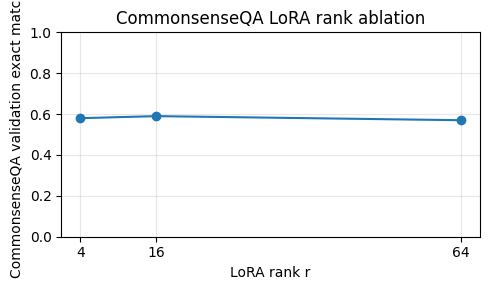

In [9]:
LORA_RANKS = [4, 16, 64]
rank_adapter_paths = {}
rank_results = []

for r in LORA_RANKS:
    adapter_name = f"commonsenseqa_lora_r{r}"
    adapter_path = train_adapter(
        records=cqa_train,
        task="CommonsenseQA",
        r=r,
        adapter_name=adapter_name,
        num_train_epochs=SPECIALIZED_EPOCHS,
    )
    rank_adapter_paths[r] = adapter_path

    acc, pred_df = evaluate_adapter(adapter_path, "CommonsenseQA", cqa_val)
    pred_df.to_csv(RESULTS_ROOT / f"commonsenseqa_rank_{r}_predictions.csv", index=False)

    rank_results.append({
        "rank": r,
        "adapter": adapter_name,
        "commonsenseqa_val_exact_match": acc,
    })

rank_results_df = pd.DataFrame(rank_results)
rank_results_df.to_csv(RESULTS_ROOT / "commonsenseqa_rank_ablation.csv", index=False)
display(rank_results_df)

plt.figure(figsize=(5, 3))
plt.plot(rank_results_df["rank"], rank_results_df["commonsenseqa_val_exact_match"], marker="o")
plt.xticks(LORA_RANKS)
plt.xlabel("LoRA rank r")
plt.ylabel("CommonsenseQA validation exact match")
plt.title("CommonsenseQA LoRA rank ablation")
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_ROOT / "commonsenseqa_rank_ablation.png", dpi=150)
plt.show()


### What to learn from the rank ablation

Look at the CommonsenseQA validation exact-match score as rank increases. A larger rank trains more adapter parameters, but the result may not improve monotonically. On small datasets, a larger adapter can also overfit or simply fail to help under a short training budget.

For the rest of the notebook we will use `r = 16` as a practical default. It is a common middle point: more capacity than `r = 4`, but cheaper than `r = 64`.


In [10]:
CHOSEN_RANK = 16
print("Chosen LoRA rank for the rest of the notebook:", CHOSEN_RANK)


Chosen LoRA rank for the rest of the notebook: 16


## Part 4 — Train the 3 specialized adapters

Using the chosen rank, we now prepare one adapter per dataset:

- GSM8K specialized adapter;
- CommonsenseQA specialized adapter;
- AG News specialized adapter.

Each specialized adapter sees only its own 300-example training split. This gives us three in-domain specialists.

The output style is task-specific. GSM8K trains on worked solutions that end with `Answer: <number>`, while CommonsenseQA and AG News train on short final-answer outputs. The CommonsenseQA adapter with `r = 16` was already trained during the rank ablation, so we reuse it instead of training the exact same adapter twice. We only need to train the GSM8K and AG News specialized adapters with `r = 16`.


In [11]:
raw = {
    task: {
        "train": load_json_split(task, "train"),
        "val": load_json_split(task, "val"),
    }
    for task in TASKS
}

summary = pd.DataFrame([
    {"task": task, "train_examples": len(raw[task]["train"]), "val_examples": len(raw[task]["val"])}
    for task in TASKS
])
display(summary)

# Inspect one example from each dataset.
for task in TASKS:
    print("\n" + "=" * 80)
    print(task)
    display(pd.DataFrame([raw[task]["train"][0]]))
    prompt, target = format_example(raw[task]["train"][0], task)
    print(prompt[:1000])
    print("TARGET:", target)


,task,train_examples,val_examples
0,GSM8K,300,100
1,CommonsenseQA,300,100
2,AGNews,300,100



GSM8K


,id,question,answer,final_answer
0,0,"For every 12 cans you recycle, you receive $0....",There are 144/12 = 12 sets of 12 cans that the...,12


Solve the following math word problem step by step.

Question: For every 12 cans you recycle, you receive $0.50, and for every 5 kilograms of newspapers, you receive $1.50. If your family collected 144 cans and 20 kilograms of newspapers, how much money would you receive?

TARGET: There are 144/12 = 12 sets of 12 cans that the family collected. So, the family would receive $0.50 x 12 = $6 for the cans. There are 20/5 = 4 sets of 5 kilograms of newspapers that the family collected. So, the family would receive $1.50 x 4 = $6 for the newspapers. Therefore, the family would receive a total of $6 + $6 = $12.
Answer: 12

CommonsenseQA


,id,question,question_concept,choices,answerKey
0,0,"I needed to send a piece of mail, where did I go?",mail,"{'label': ['A', 'B', 'C', 'D', 'E'], 'text': [...",B


Choose the best answer.

Question: I needed to send a piece of mail, where did I go?

A. table
B. post office
C. neighbor's house
D. railway station
E. fridge

TARGET: Answer: B

AGNews


,label,title,description,id
0,1,Policeman 'saw fatal train crash',An off-duty policeman watched a train plough i...,0


Classify the news article into one of: World, Sports, Business, Sci/Tech.

Title: Policeman 'saw fatal train crash'
Description: An off-duty policeman watched a train plough into a car on a level crossing  in Berkshire, killing six people.

TARGET: Answer: World


In [12]:
# Baseline: evaluate the original base model without any LoRA adapter.
#
# This gives us a reference point. If an adapter does not beat the base model
# on its own task, then fine-tuning may not be helping yet.

base_model = load_base_model_for_evaluation()

base_scores = {}
base_prediction_tables = {}

for task in TASKS:
    print("\n" + "=" * 80)
    print("Evaluating base model on:", task)

    acc, pred_df = evaluate_loaded_model(
        base_model,
        task,
        raw[task]["val"],
        limit=EVAL_LIMIT,
    )

    base_scores[task] = acc
    base_prediction_tables[task] = pred_df

    pred_df.to_csv(
        RESULTS_ROOT / f"base_model_{task.lower()}_predictions.csv",
        index=False,
    )

base_eval_df = (
    pd.DataFrame.from_dict(base_scores, orient="index", columns=["Base model"])
    .rename_axis("dataset")
)

base_eval_df.to_csv(RESULTS_ROOT / "base_model_eval.csv")
display(base_eval_df.style.format("{:.3f}"))

del base_model
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)



Evaluating base model on: GSM8K


Eval GSM8K:   0%|          | 0/25 [00:00<?, ?it/s]


Evaluating base model on: CommonsenseQA


Eval CommonsenseQA:   0%|          | 0/25 [00:00<?, ?it/s]


Evaluating base model on: AGNews


Eval AGNews:   0%|          | 0/25 [00:00<?, ?it/s]

,Base model
dataset,
GSM8K,0.000
CommonsenseQA,0.400
AGNews,0.040


In [13]:
specialized_adapters = {
    "CommonsenseQA": rank_adapter_paths[CHOSEN_RANK]
}

for task in ["GSM8K", "AGNews"]:
    specialized_adapters[task] = train_adapter(
        records=raw[task]["train"],
        task=task,
        r=CHOSEN_RANK,
        adapter_name=f"{task.lower()}_specialized_r{CHOSEN_RANK}",
        num_train_epochs=SPECIALIZED_EPOCHS,
    )

# Keep the display order consistent with TASKS.
specialized_adapters = {task: specialized_adapters[task] for task in TASKS}

specialized_self_results = []
for task, adapter_path in specialized_adapters.items():
    acc, pred_df = evaluate_adapter(adapter_path, task, raw[task]["val"])
    pred_df.to_csv(RESULTS_ROOT / f"{task.lower()}_specialized_self_predictions.csv", index=False)
    specialized_self_results.append({
        "task": task,
        "adapter": f"{task} specialized",
        "val_exact_match": acc,
    })

specialized_self_eval_df = pd.DataFrame(specialized_self_results)
specialized_self_eval_df.to_csv(RESULTS_ROOT / "specialized_self_eval.csv", index=False)
display(specialized_self_eval_df)



Training adapter: gsm8k_specialized_r16
Training examples: 300
Training mode: epoch-based
Requested epochs: 4


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


trainable params: 8,798,208 || all params: 502,830,976 || trainable%: 1.7497

Trainer sanity check
Trainer sees CUDA devices: 1
Trainer per-device batch size: 3
Trainer global train batch size: 3
Trainer gradient accumulation: 5
Micro-batches per epoch: 100
Optimizer updates per epoch: 20
Trainer max_steps: -1
Trainer num_train_epochs: 4.0


Step,Training Loss
10,0.844682
20,0.640253
30,0.493915
40,0.494019
50,0.363480
60,0.351038
70,0.267779
80,0.267010


...

Eval CommonsenseQA:   0%|          | 0/25 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Eval AGNews:   0%|          | 0/25 [00:00<?, ?it/s]

,task,adapter,val_exact_match
0,GSM8K,GSM8K specialized,0.04
1,CommonsenseQA,CommonsenseQA specialized,0.59
2,AGNews,AGNews specialized,0.87


### What to look for after specialized training

The self-evaluation table checks each specialized adapter on its own validation set. These numbers are not yet the full transfer result. They simply tell us whether each adapter learned something useful for its own task.

The final cross-task matrix comes later.


## Part 5 — Train the general adapter with matched budget

The general adapter is trained on the union of all three training sets:

```text
300 GSM8K + 300 CommonsenseQA + 300 AG News = 900 examples
```

A tempting but unfair experiment would train this mixed dataset for the same number of epochs as each specialized adapter. That gives the general adapter about three times as many optimizer updates.

Instead, we match the budget. The specialized adapters are trained epoch-by-epoch on their own 300-example datasets. We compute the number of optimizer updates that corresponds to one specialized run, then train the general adapter for that same number of optimizer updates on the shuffled 900-example mixed dataset.

This budget matching is important because we want to compare **specialization vs generalization**, not **less training vs more training**.


In [14]:
general_updates_per_epoch = optimizer_steps_for_dataset(900, 1)
matched_general_epochs = SPECIALIZED_UPDATE_BUDGET / general_updates_per_epoch

budget_df = pd.DataFrame([
    {
        "run": "one specialized adapter",
        "training_examples": 300,
        "training_mode": "epoch-based",
        "epochs": SPECIALIZED_EPOCHS,
        "optimizer_updates_used": SPECIALIZED_UPDATE_BUDGET,
    },
    {
        "run": "general adapter, matched budget",
        "training_examples": 900,
        "training_mode": "step-based",
        "epochs": matched_general_epochs,
        "optimizer_updates_used": SPECIALIZED_UPDATE_BUDGET,
    },
])

display(budget_df)

mixed_train = []
for task in TASKS:
    for ex in raw[task]["train"]:
        mixed_train.append({**ex, "_task": task})

random.Random(SEED).shuffle(mixed_train)

print("Mixed training examples:", len(mixed_train))
display(
    pd.Series([ex["_task"] for ex in mixed_train])
    .value_counts()
    .rename("count")
    .to_frame()
)

general_adapter_path = train_adapter(
    records=mixed_train,
    task=None,
    r=CHOSEN_RANK,
    adapter_name=f"general_matched_r{CHOSEN_RANK}",
    max_steps=SPECIALIZED_UPDATE_BUDGET,
)

,run,training_examples,training_mode,epochs,optimizer_updates_used
0,one specialized adapter,300,epoch-based,4.000000,80
1,"general adapter, matched budget",900,step-based,1.333333,80


Mixed training examples: 900


,count
GSM8K,300
AGNews,300
CommonsenseQA,300



Training adapter: general_matched_r16
Training examples: 900
Training mode: step-based
Requested optimizer updates: 80


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


trainable params: 8,798,208 || all params: 502,830,976 || trainable%: 1.7497

Trainer sanity check
Trainer sees CUDA devices: 1
Trainer per-device batch size: 3
Trainer global train batch size: 3
Trainer gradient accumulation: 5
Micro-batches per epoch: 300
Optimizer updates per epoch: 60
Trainer max_steps: 80
Trainer num_train_epochs: 1


Step,Training Loss
10,1.464090
20,0.550357
30,0.566480
40,0.608431
50,0.605338
60,0.636236
70,0.411348
80,0.457942


### What the matched budget changes conceptually

The general adapter must spend the same number of updates across three tasks. This makes the comparison stricter. If the general adapter performs well, it is evidence that mixed-task training helped transfer or shared behavior. If it performs worse in-domain than specialists, that may reflect the cost of sharing a fixed budget across tasks.


## Part 6 — Final evaluation: base model + 4 adapters × 3 datasets

This is the main result of the homework.

We evaluate the frozen base model as a baseline, followed by four trained adapters:

- GSM8K specialized adapter;
- CommonsenseQA specialized adapter;
- AG News specialized adapter;
- General matched-budget adapter.

Each model or adapter is evaluated on all three validation datasets. The final result is a **3 × 5 table**:

- rows = validation datasets;
- columns = base model plus adapters.

For GSM8K, evaluation extracts the final number after the generated `Answer:` marker, even though the model is allowed to produce step-by-step reasoning before that final line. For CommonsenseQA and AG News, evaluation checks the short final answer directly.

The diagonal entries show in-domain performance for the specialized adapters. Off-diagonal entries show cross-task transfer. The base-model column tells us how much adaptation changed performance relative to the original model.


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Eval GSM8K:   0%|          | 0/25 [00:00<?, ?it/s]

Eval CommonsenseQA:   0%|          | 0/25 [00:00<?, ?it/s]

Eval AGNews:   0%|          | 0/25 [00:00<?, ?it/s]

...

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Eval GSM8K:   0%|          | 0/25 [00:00<?, ?it/s]

Eval CommonsenseQA:   0%|          | 0/25 [00:00<?, ?it/s]

Eval AGNews:   0%|          | 0/25 [00:00<?, ?it/s]

,Base model,GSM8K specialized,CommonsenseQA specialized,AG News specialized,General matched
dataset,,,,,
GSM8K,0.000,0.040,0.010,0.000,0.050
CommonsenseQA,0.400,0.580,0.590,0.560,0.590
AGNews,0.040,0.140,0.420,0.870,0.810


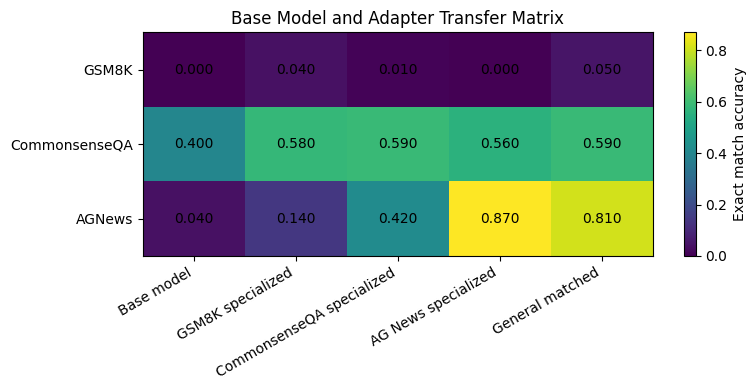

In [15]:
final_adapters = {
    "GSM8K specialized": specialized_adapters["GSM8K"],
    "CommonsenseQA specialized": specialized_adapters["CommonsenseQA"],
    "AG News specialized": specialized_adapters["AGNews"],
    "General matched": general_adapter_path,
}

# onstruct the final transfer matrix.
#
# Requirements:
# - rows should be validation datasets: GSM8K, CommonsenseQA, AGNews
# - columns should include the Base model and the four trained adapters above
# - each cell should contain exact-match accuracy
# - save the table to RESULTS_ROOT / "final_transfer_matrix_with_base.csv"
# - display the table and plot a clean annotated heatmap
#
# You may use base_scores and base_prediction_tables for the base-model column.
# For adapter columns, load each adapter once and evaluate it on all three datasets.

transfer_df = pd.DataFrame(index=TASKS)

transfer_df["Base model"] = [
    base_scores["GSM8K"],
    base_scores["CommonsenseQA"],
    base_scores["AGNews"],
]

for adapter_name, adapter_path in final_adapters.items():
    model = load_model_with_adapter(adapter_path)

    scores = []
    for task in TASKS:
        acc, pred_df = evaluate_loaded_model(
            model,
            task,
            raw[task]["val"],
            limit=EVAL_LIMIT,
        )

        pred_df.to_csv(
            RESULTS_ROOT
            / f"{adapter_name.lower().replace(' ', '_')}_{task.lower()}_predictions.csv",
            index=False,
        )

        scores.append(acc)

    transfer_df[adapter_name] = scores

    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

transfer_df.index.name = "dataset"

transfer_df.to_csv(
    RESULTS_ROOT / "final_transfer_matrix_with_base.csv"
)

display(transfer_df.style.format("{:.3f}"))

plt.figure(figsize=(8, 4))

im = plt.imshow(
    transfer_df.values,
    aspect="auto",
)

plt.xticks(
    range(len(transfer_df.columns)),
    transfer_df.columns,
    rotation=30,
    ha="right",
)

plt.yticks(
    range(len(transfer_df.index)),
    transfer_df.index,
)

for i in range(len(transfer_df.index)):
    for j in range(len(transfer_df.columns)):
        plt.text(
            j,
            i,
            f"{transfer_df.iloc[i, j]:.3f}",
            ha="center",
            va="center",
        )

plt.colorbar(im, label="Exact match accuracy")
plt.title("Base Model and Adapter Transfer Matrix")
plt.tight_layout()
plt.savefig(
    RESULTS_ROOT / "final_transfer_matrix_with_base.png",
    dpi=150,
)
plt.show()

### Reading the transfer matrix

A strong diagonal means specialization helps in-domain performance. Strong off-diagonal scores mean an adapter transfers to other tasks. The general adapter column is especially important: it shows whether one mixed adapter can cover several task formats under the same optimizer budget as a specialist.

For GSM8K, remember that the score only checks the final extracted number; it does not judge whether every reasoning step is correct. The generations are still useful to inspect qualitatively, because a model can sometimes land on the right number for the wrong reason, or make a good reasoning attempt with a small arithmetic mistake.

The base-model column is the reference point. An adapter is useful only if it improves the relevant behavior compared with the frozen model, or if it gives a favorable trade-off across tasks.


In [16]:
# A compact way to compare average performance across datasets.
model_average = transfer_df.mean(axis=0).sort_values(ascending=False).rename("mean_exact_match")
display(model_average.to_frame().style.format("{:.3f}"))

# Improvement over the original base model.
improvement_over_base = transfer_df.subtract(transfer_df["Base model"], axis=0)
display(improvement_over_base.style.format("{:+.3f}"))


,mean_exact_match
General matched,0.483
AG News specialized,0.477
CommonsenseQA specialized,0.340
GSM8K specialized,0.253
Base model,0.147


,Base model,GSM8K specialized,CommonsenseQA specialized,AG News specialized,General matched
dataset,,,,,
GSM8K,+0.000,+0.040,+0.010,+0.000,+0.050
CommonsenseQA,+0.000,+0.180,+0.190,+0.160,+0.190
AGNews,+0.000,+0.100,+0.380,+0.830,+0.770
